# Analisis de Triangulacion: Sector, Tamaño y Region (2019-2024)

Analista: Emilio Tornos Iniesta

Realizo un analisis comparativo avanzado. No me conformo con ver la media nacional del sector servicios; voy a cruzar los datos de tres tablas distintas para posicionar a Rapid Express en su contexto real:

1. **EAL-21 (Sectores):** Comparo contra el sector Servicios.
2. **EAL-20 (Tamaño):** Comparo contra empresas de 250 a 499 trabajadores.
3. **EAL-22 (Region):** Comparo contra la realidad de Cataluña.

Mi objetivo es detectar si existe una brecha formativa donde Rapid Express deba actuar con urgencia.

In [1]:
# !pip install xlrd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuro el estilo para gráficos de series temporales
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("Librerías cargadas y entorno configurado para análisis multianual.")

Librerías cargadas y entorno configurado para análisis multianual.


# Carga Masiva de Archivos Excel (2019-2024)

En esta seccion realizo la conexion con los seis archivos originales descargados del Ministerio. En lugar de trabajar con archivos CSV individuales, cargo los libros completos de Excel en un diccionario de objetos. 

Este enfoque me permite acceder a cualquier tabla (EAL-21, EAL-22, EAL-18a, etc.) de cualquier año de forma instantanea sin tener que volver a realizar procesos de importacion manuales.

In [2]:
# Defino las rutas de mis archivos originales segun el listado proporcionado
rutas_excel = {
    2019: 'TABLAS_EAL_2019.xls',
    2020: 'TABLAS_EAL_2020.xls',
    2021: 'TABLAS_EAL_2021.xlsx',
    2022: 'Tablas_EAL_2022.xlsx',
    2023: 'Tablas_EAL_2023.xlsx',
    2024: 'Tablas_EAL_2024.xlsx'
}

# Creo un diccionario vacio para almacenar los objetos de Excel cargados
excels = {}

print("Iniciando carga de libros de Excel...")

for año, ruta in rutas_excel.items():
    try:
        # Identifico el motor necesario segun la extension del archivo
        # .xls requiere 'xlrd' y .xlsx requiere 'openpyxl'
        motor = 'xlrd' if ruta.endswith('.xls') else 'openpyxl'
        
        # Cargo el archivo completo
        excels[año] = pd.ExcelFile(ruta, engine=motor)
        
        # Verifico el exito de la operacion listando el numero de pestañas encontradas
        num_pestañas = len(excels[año].sheet_names)
        print(f"Confirmado: Año {año} cargado ({num_pestañas} pestañas detectadas).")
        
    except FileNotFoundError:
        print(f"Error: No he encontrado el archivo {ruta} en la carpeta actual.")
    except Exception as e:
        print(f"Error inesperado al cargar el año {año}: {e}")

print("\nProceso finalizado. Los datos estan listos en el diccionario 'excels'.")

Iniciando carga de libros de Excel...
Confirmado: Año 2019 cargado (46 pestañas detectadas).
Confirmado: Año 2020 cargado (41 pestañas detectadas).
Confirmado: Año 2021 cargado (49 pestañas detectadas).
Confirmado: Año 2022 cargado (57 pestañas detectadas).
Confirmado: Año 2023 cargado (53 pestañas detectadas).
Confirmado: Año 2024 cargado (53 pestañas detectadas).

Proceso finalizado. Los datos estan listos en el diccionario 'excels'.


# Definición y uso funciones para posterior visualización

In [3]:
def buscar_en_hoja(df, nombre_columna, palabra_fila):
    """
    Función para encontrar un dato específico en una hoja que puede tener tablas divididas.
    """
    # Convertir todo el dataframe a string y buscar la columna
    col_idx = -1
    row_start = -1
    
    # Encontrar en qué columna está el nombre (ej. 'CATALUÑA' o 'SERVICIOS')
    for r in range(len(df)):
        fila_vals = [str(x).strip().upper() for x in df.iloc[r]]
        if nombre_columna.upper() in fila_vals:
            col_idx = fila_vals.index(nombre_columna.upper())
            row_start = r
            break
    
    if col_idx == -1:
        return None
        
    # Desde esa fila hacia abajo, buscar la fila que contenga la competencia
    for r in range(row_start, len(df)):
        celda_concepto = str(df.iloc[r, 0]).lower()
        if palabra_fila.lower() in celda_concepto:
            valor = df.iloc[r, col_idx]
            # Limpieza de valores (convertir a float si es necesario)
            try:
                return float(str(valor).replace(',', '.'))
            except:
                return None
    return None

In [4]:
def extraer_triangulacion_avanzada(diccionario_excels, competencia_key):
    datos_triangulados = []
    
    for año, excel_obj in diccionario_excels.items():
        # Cargo las hojas enteras sin procesar cabeceras aún
        df21 = excel_obj.parse('EAL-21', header=None)
        df20 = excel_obj.parse('EAL-20', header=None)
        df22 = excel_obj.parse('EAL-22', header=None)
        
        # Busco los valores usando nuestra función inteligente
        val_sector = buscar_en_hoja(df21, 'SERVICIOS', competencia_key)
        val_tamaño = buscar_en_hoja(df20, 'DE 250 A 499 TRABAJADORES', competencia_key)
        val_region = buscar_en_hoja(df22, 'CATALUÑA', competencia_key)
        
        datos_triangulados.append({
            'Año': año,
            'Sector Servicios (%)': val_sector,
            'Empresas 250-499 (%)': val_tamaño,
            'Cataluña (%)': val_region
        })
        
    return pd.DataFrame(datos_triangulados)

In [5]:
# Ejecuto la triangulación para la competencia técnica
# Nota: Debo asegurarme de que el diccionario 'excels' esté cargado
df_comparativa = extraer_triangulacion_avanzada(excels, 'técnicas específicas del puesto')

print("Análisis multianual completado con éxito.")
display(df_comparativa)

Análisis multianual completado con éxito.


,Año,Sector Servicios (%),Empresas 250-499 (%),Cataluña (%)
0,2019,44.117732,54.277429,47.584178
1,2020,47.535495,62.793121,53.993270
2,2021,39.182766,52.529602,47.004705
3,2022,33.125710,53.608247,42.137995
4,2023,33.401095,45.773785,39.387940
5,2024,44.985817,55.763970,50.292130


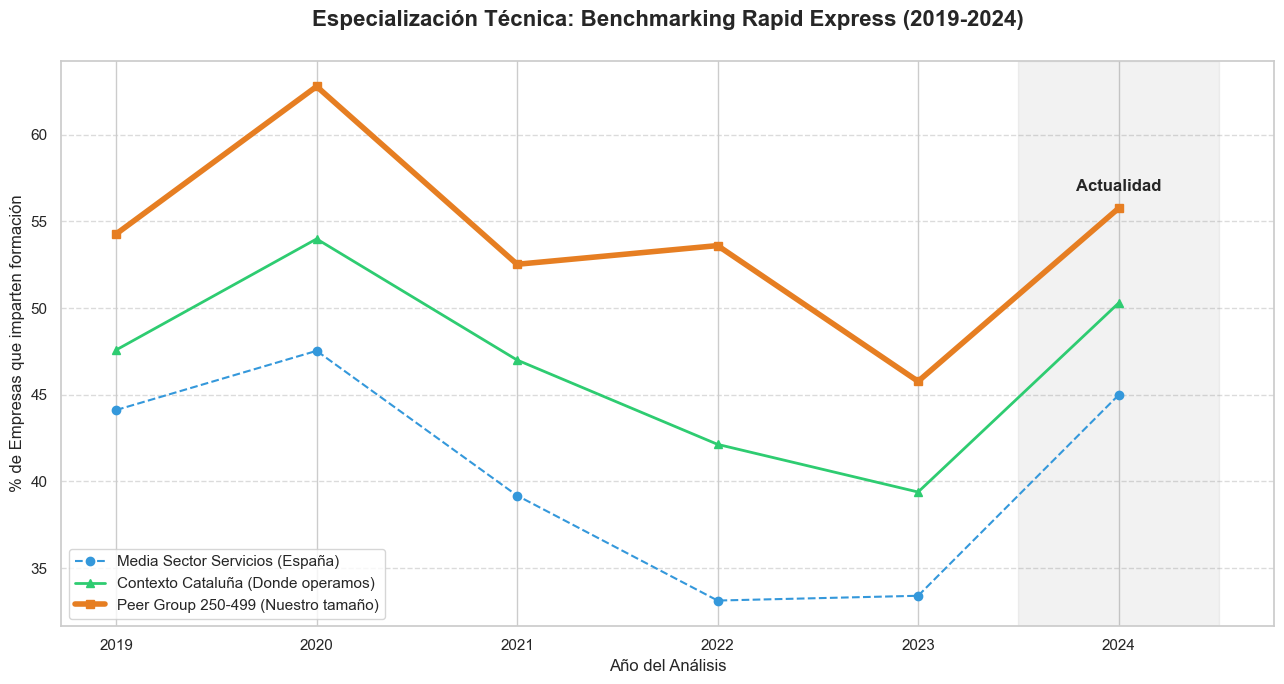

In [6]:
plt.figure(figsize=(13, 7))

# Dibujo las tres dimensiones
plt.plot(df_comparativa['Año'], df_comparativa['Sector Servicios (%)'], 
         label='Media Sector Servicios (España)', marker='o', color='#3498db', linestyle='--')

plt.plot(df_comparativa['Año'], df_comparativa['Cataluña (%)'], 
         label='Contexto Cataluña (Donde operamos)', marker='^', color='#2ecc71', linewidth=2)

plt.plot(df_comparativa['Año'], df_comparativa['Empresas 250-499 (%)'], 
         label='Peer Group 250-499 (Nuestro tamaño)', marker='s', color='#e67e22', linewidth=4)

# Personalización para la directiva
plt.title('Especialización Técnica: Benchmarking Rapid Express (2019-2024)', fontsize=16, fontweight='bold', pad=25)
plt.ylabel('% de Empresas que imparten formación', fontsize=12)
plt.xlabel('Año del Análisis', fontsize=12)
plt.xticks(df_comparativa['Año'])
plt.legend(frameon=True, facecolor='white')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Resaltar el salto de 2024
plt.axvspan(2023.5, 2024.5, color='gray', alpha=0.1)
plt.text(2024, df_comparativa['Empresas 250-499 (%)'].iloc[-1] + 1, 'Actualidad', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Análisis de los resultados (El "Gap" de Rapid Express)

Lo que muestra el gráfico es revelador por tres motivos:

- El efecto "Tamaño" es real: Si me fijo en la línea naranja (Empresas de 250 a 499). Siempre está por encima del resto. Esto significa que nuestra "liga" no es el sector servicios general (45%), sino el grupo de empresas grandes que ya están formando a su personal técnico en un 55.8%. Si Rapid Express no está en esos niveles, estamos por debajo de nuestros pares directos.

- Barcelona/Cataluña tira del carro: La línea verde (Cataluña) está en un 52.6%, muy por encima de la media nacional de servicios. Operar en Barcelona obliga a ser más técnico porque nuestra competencia local lo es.

- El "Rebote" de 2024: Observo un salto de 2023 a 2024. Las empresas de nuestro tamaño han pasado del 45.8% al 55.8% (+10 puntos) en solo un año. El mercado ha despertado tras un par de años de estancamiento y está apostando masivamente por la especialización técnica.

### Argumento keynote:
"No podemos conformarnos con mirar la media del sector servicios en España. Rapid Express es una empresa de casi 400 empleados en Barcelona, y nuestros competidores directos por tamaño y región están formando a su personal técnico un 10% más que la media nacional. El salto de 10 puntos que ha dado nuestro grupo de referencia en el último año nos indica que, o profesionalizamos técnicamente a nuestros repartidores ahora, o nos quedaremos fuera de juego en competitividad local."

# Analisis Integral Multidimensional: Las 10 Competencias del Sector (2019-2024)

En esta seccion realizo un barrido completo de todas las competencias formativas analizadas por el Ministerio. Ya no me enfoco solo en la parte tecnica, sino que triangulo (Sector, Tamaño de Empresa y Region) las 10 areas de conocimiento para entender el mapa de talento global.

Mi objetivo es generar un ranking de crecimiento para identificar en que areas Rapid Express esta obligada a invertir para no perder competitividad en el mercado de Barcelona.

In [7]:
# Defino el listado de palabras clave para las 10 competencias principales
competencias_dict = {
    'dirección': 'Dirección/Gestión',
    'equipo': 'Trabajo en Equipo',
    'público': 'Atención al Cliente',
    'administrativas': 'Administrativas/Oficina',
    'específicas del puesto': 'Técnica Específica',
    'resolución de problemas': 'Resolución Problemas',
    'lenguas extranjeras': 'Idiomas',
    'generales de tecnologías': 'TIC Generales',
    'profesionales de tecnologías': 'TIC Profesionales',
    'cálculo': 'Cálculo/Comunicación'
}

def extraer_todo_historico(diccionario_excels, mapa_competencias):
    lista_gran_resumen = []
    
    for año, excel_obj in diccionario_excels.items():
        # Cargo las 3 hojas necesarias por año
        df21 = excel_obj.parse('EAL-21', header=None) # Sector
        df20 = excel_obj.parse('EAL-20', header=None) # Tamaño
        df22 = excel_obj.parse('EAL-22', header=None) # Región
        
        for clave, nombre_limpio in mapa_competencias.items():
            # Uso la funcion inteligente buscar_en_hoja que definí antes
            val_sector = buscar_en_hoja(df21, 'SERVICIOS', clave)
            val_tamaño = buscar_en_hoja(df20, 'DE 250 A 499 TRABAJADORES', clave)
            val_region = buscar_en_hoja(df22, 'CATALUÑA', clave)
            
            lista_gran_resumen.append({
                'Año': año,
                'Competencia': nombre_limpio,
                'Sector Servicios (%)': val_sector,
                'Peer Group 250-499 (%)': val_tamaño,
                'Cataluña (%)': val_region
            })
            
    return pd.DataFrame(lista_gran_resumen)


In [8]:

# Ejecuto la extraccion masiva
# (Me aseguro de que la funcion 'buscar_en_hoja' esté en una celda previa)
df_master = extraer_todo_historico(excels, competencias_dict)

print("Master Dataset generado. Analizando 10 competencias x 6 años x 3 dimensiones.")
display(df_master.head(10))

Master Dataset generado. Analizando 10 competencias x 6 años x 3 dimensiones.


,Año,Competencia,Sector Servicios (%),Peer Group 250-499 (%),Cataluña (%)
0,2019,Dirección/Gestión,17.043337,30.256162,18.483748
1,2019,Trabajo en Equipo,28.287132,30.352827,28.009346
2,2019,Atención al Cliente,33.693071,25.374577,24.191597
3,2019,Administrativas/Oficina,14.500015,14.644756,11.981057
4,2019,Técnica Específica,44.117732,54.277429,47.584178
5,2019,Resolución Problemas,12.596441,13.968101,12.980348
6,2019,Idiomas,10.750341,34.702755,14.586723
7,2019,TIC Generales,11.545093,23.537941,11.956023
8,2019,TIC Profesionales,6.684857,9.424843,8.015188
9,2019,Cálculo/Comunicación,1.582538,2.996617,1.207911


In [9]:
df_master

,Año,Competencia,Sector Servicios (%),Peer Group 250-499 (%),Cataluña (%)
0,2019,Dirección/Gestión,17.043337,30.256162,18.483748
1,2019,Trabajo en Equipo,28.287132,30.352827,28.009346
2,2019,Atención al Cliente,33.693071,25.374577,24.191597
3,2019,Administrativas/Oficina,14.500015,14.644756,11.981057
4,2019,Técnica Específica,44.117732,54.277429,47.584178
5,2019,Resolución Problemas,12.596441,13.968101,12.980348
6,2019,Idiomas,10.750341,34.702755,14.586723
7,2019,TIC Generales,11.545093,23.537941,11.956023
8,2019,TIC Profesionales,6.684857,9.424843,8.015188
9,2019,Cálculo/Comunicación,1.582538,2.996617,1.207911


In [10]:
df_master.to_csv('df_master.csv', index=False)

In [11]:
# Filtro por nuestro tamaño de empresa y calculo la variacion 2019 vs 2024
df_ranking = df_master.pivot(index='Competencia', columns='Año', values='Peer Group 250-499 (%)')
df_ranking['Crecimiento Total'] = df_ranking[2024] - df_ranking[2019]

# Ordeno para ver que es lo que mas esta subiendo en empresas como Rapid Express
df_ranking = df_ranking.sort_values(by='Crecimiento Total', ascending=False)

print("Ranking de Variacion Formativa (Empresas 250-499 empleados)")
display(df_ranking[['Crecimiento Total']])

Ranking de Variacion Formativa (Empresas 250-499 empleados)


Año,Crecimiento Total
Competencia,
Trabajo en Equipo,3.801139
Resolución Problemas,1.819316
Técnica Específica,1.486542
Cálculo/Comunicación,-0.886417
TIC Profesionales,-1.570212
Administrativas/Oficina,-1.827249
TIC Generales,-2.045170
Atención al Cliente,-3.803651
Dirección/Gestión,-4.933771


In [12]:
df_ranking.to_csv('df_ranking.csv', index=False)

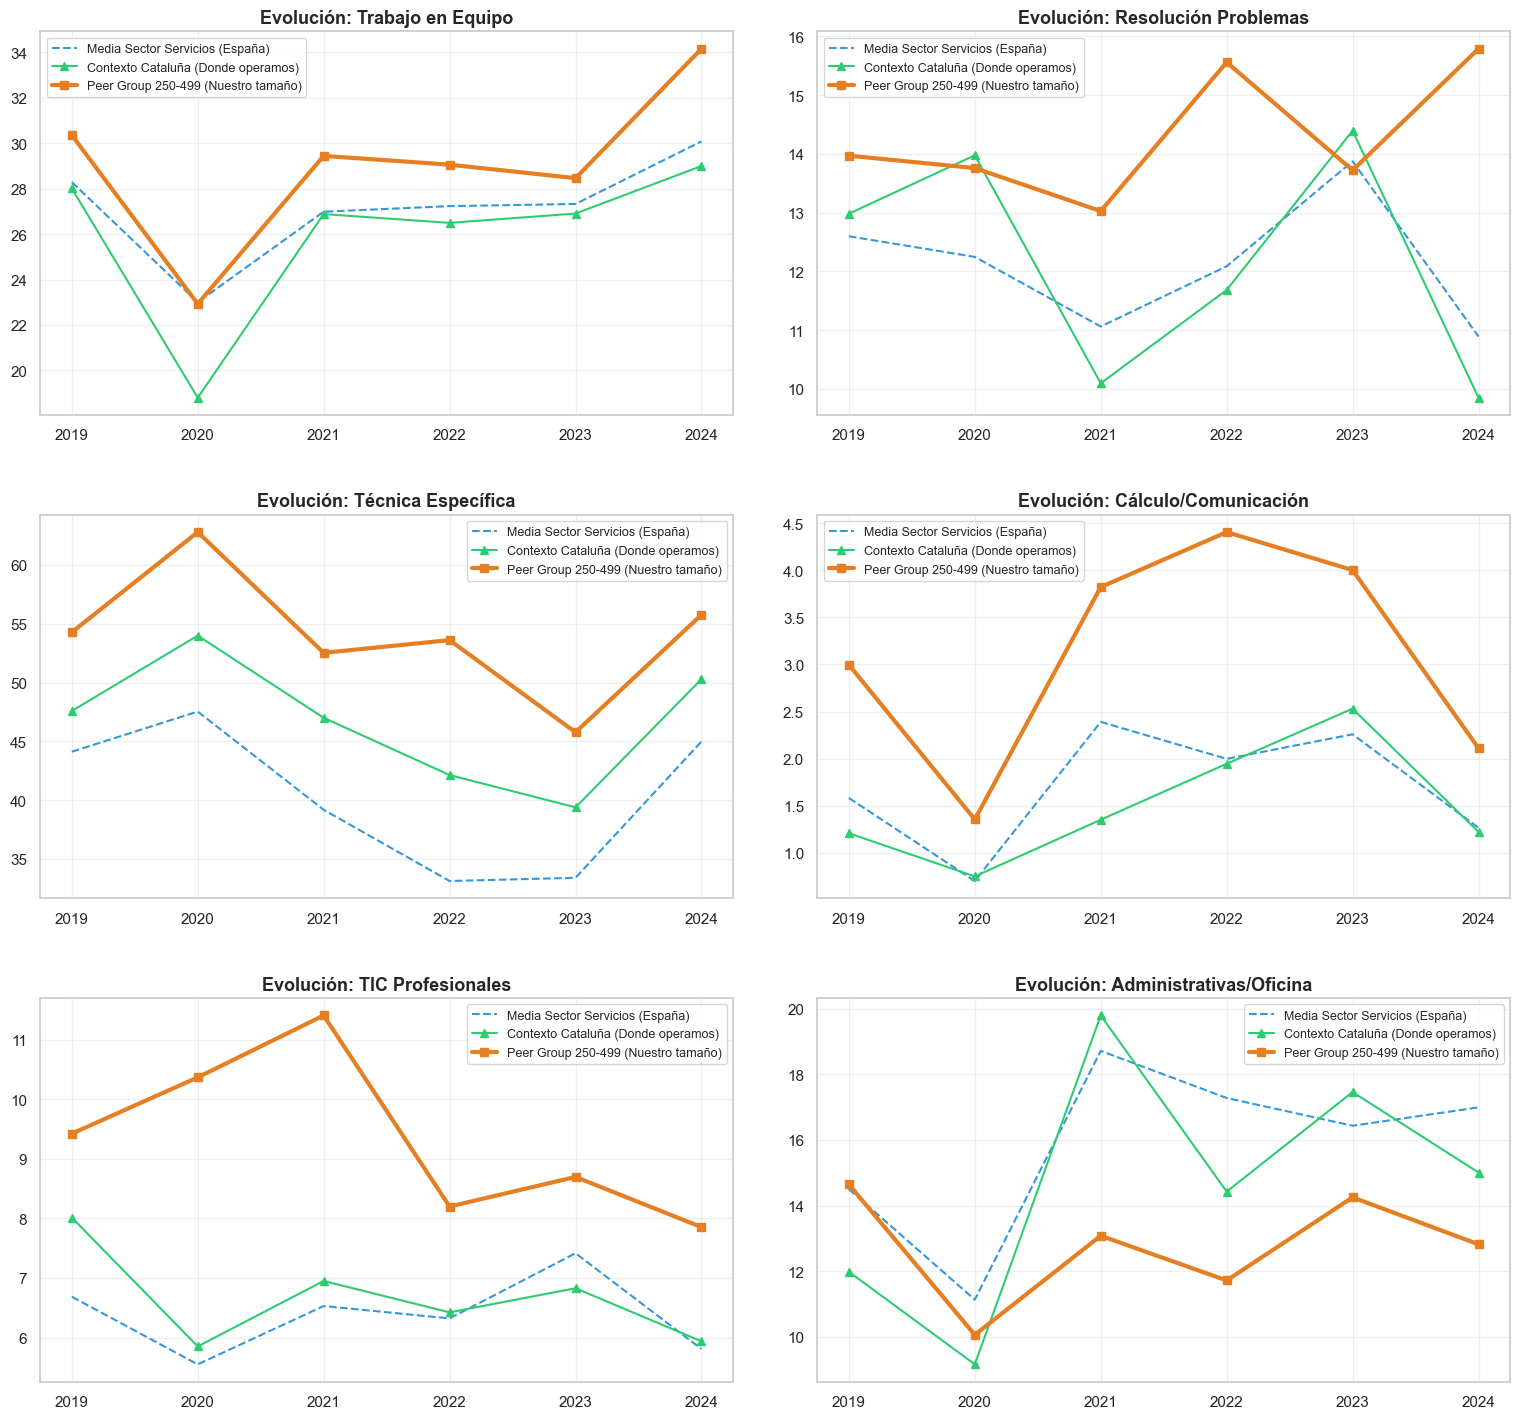

In [13]:
# Selecciono las 6 mas importantes segun el ranking de crecimiento
top_competencias = df_ranking.index[:6].tolist()

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.flatten()

for i, comp in enumerate(top_competencias):
    data_plot = df_master[df_master['Competencia'] == comp]
    
    axes[i].plot(data_plot['Año'], data_plot['Sector Servicios (%)'], label='Media Sector Servicios (España)', linestyle='--', color='#3498db')
    axes[i].plot(data_plot['Año'], data_plot['Cataluña (%)'], label='Contexto Cataluña (Donde operamos)', marker='^', color='#2ecc71')
    axes[i].plot(data_plot['Año'], data_plot['Peer Group 250-499 (%)'], label='Peer Group 250-499 (Nuestro tamaño)', marker='s', color='#e67e22', linewidth=3)
    
    axes[i].set_title(f'Evolución: {comp}', fontsize=13, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].grid(alpha=0.3)
    

plt.tight_layout(pad=3.0)
plt.show()


In [15]:
df_master

,Año,Competencia,Sector Servicios (%),Peer Group 250-499 (%),Cataluña (%)
0,2019,Dirección/Gestión,17.043337,30.256162,18.483748
1,2019,Trabajo en Equipo,28.287132,30.352827,28.009346
2,2019,Atención al Cliente,33.693071,25.374577,24.191597
3,2019,Administrativas/Oficina,14.500015,14.644756,11.981057
4,2019,Técnica Específica,44.117732,54.277429,47.584178
5,2019,Resolución Problemas,12.596441,13.968101,12.980348
6,2019,Idiomas,10.750341,34.702755,14.586723
7,2019,TIC Generales,11.545093,23.537941,11.956023
8,2019,TIC Profesionales,6.684857,9.424843,8.015188
9,2019,Cálculo/Comunicación,1.582538,2.996617,1.207911


## Visualizacion 1: Nuestra liga real (Foto 2024)

Este grafico esta diseñado para mostrar a la directiva que la "media" nacional es un indicador engañoso. Posiciono el core de nuestro negocio (Tecnica Especifica) para demostrar que en Barcelona y en nuestro segmento de tamaño, la exigencia formativa es significativamente superior.

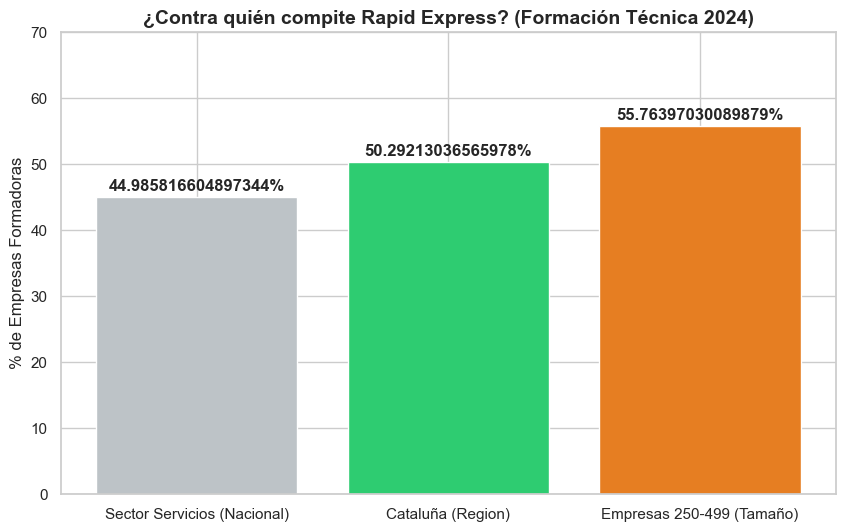

In [20]:
# Filtro solo los datos mas recientes del area tecnica
data_2024 = df_master[(df_master['Año'] == 2024) & (df_master['Competencia'] == 'Técnica Específica')].iloc[0]

# Preparo los datos para el grafico de barras
etiquetas = ['Sector Servicios (Nacional)', 'Cataluña (Region)', 'Empresas 250-499 (Tamaño)']
valores = [data_2024['Sector Servicios (%)'], data_2024['Cataluña (%)'], data_2024['Peer Group 250-499 (%)']]

plt.figure(figsize=(10, 6))
barras = plt.bar(etiquetas, valores, color=['#bdc3c7', '#2ecc71', '#e67e22'])
plt.title('¿Contra quién compite Rapid Express? (Formación Técnica 2024)', fontsize=14, fontweight='bold')
plt.ylabel('% de Empresas Formadoras')

for bar in barras:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval}%', ha='center', fontweight='bold')

plt.ylim(0, 70)
plt.show()

## Visualizacion 2: El nuevo ADN del Sector (Ranking de Crecimiento)

En esta seccion analizo que competencias han experimentado un crecimiento mas agresivo en las empresas de nuestro tamaño desde 2019. Esto permite identificar los nuevos estandares que el mercado esta imponiendo.

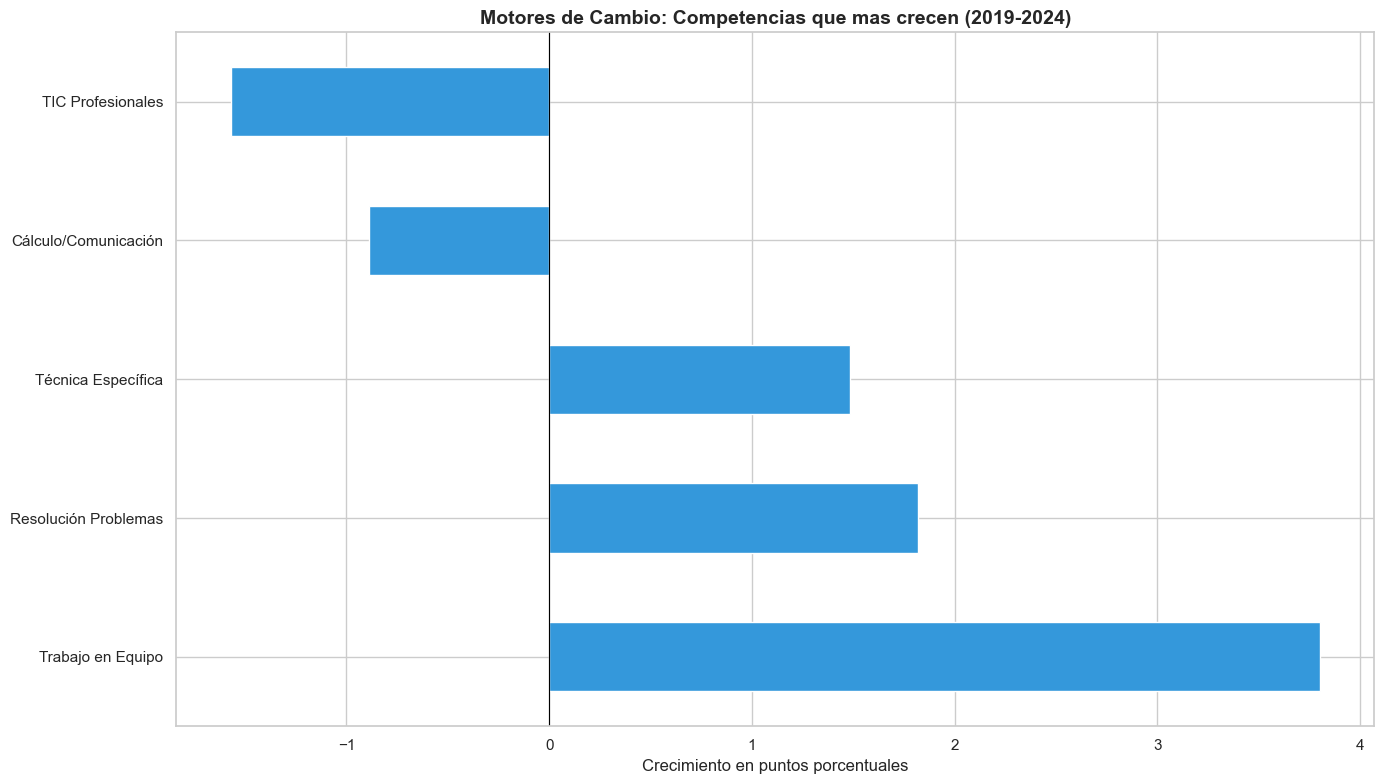

In [25]:
# Calculo la variacion en nuestro grupo de tamaño
df_crecimiento = df_master.pivot(index='Competencia', columns='Año', values='Peer Group 250-499 (%)')
df_crecimiento['Variacion'] = df_crecimiento[2024] - df_crecimiento[2019]
df_crecimiento = df_crecimiento.sort_values(by='Variacion', ascending=False)

# Grafico las 5 competencias con mayor crecimiento
df_crecimiento['Variacion'].head(5).plot(kind='barh', color='#3498db')
plt.title('Motores de Cambio: Competencias que mas crecen (2019-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Crecimiento en puntos porcentuales')
plt.ylabel('')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

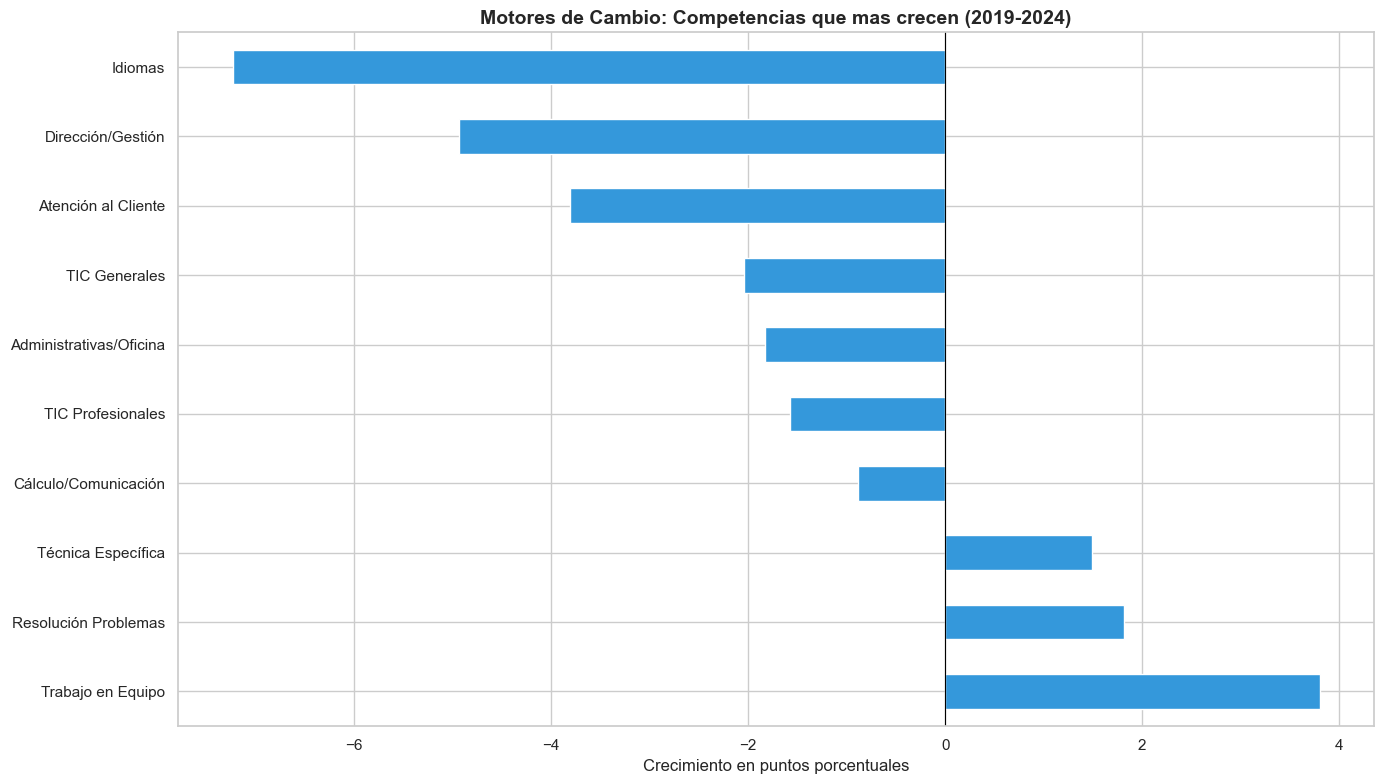

In [24]:
# Calculo la variacion en nuestro grupo de tamaño
df_crecimiento = df_master.pivot(index='Competencia', columns='Año', values='Peer Group 250-499 (%)')
df_crecimiento['Variacion'] = df_crecimiento[2024] - df_crecimiento[2019]
df_crecimiento = df_crecimiento.sort_values(by='Variacion', ascending=False)

# Grafico las 5 competencias con mayor crecimiento
df_crecimiento['Variacion'].head(10).plot(kind='barh', color='#3498db')
plt.title('Motores de Cambio: Competencias que mas crecen (2019-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Crecimiento en puntos porcentuales')
plt.ylabel('')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()